In [1]:
!pip install -q gradio piqa
import math
import os

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from torchvision.utils import make_grid
from piqa import SSIM, PSNR
import gradio as gr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Accelerating computations on: {device}")


Accelerating computations on: cuda


In [2]:
IMG_SIZE = 128
BATCH_SIZE = 32
CHANNELS = 3
TIMESTEPS = 300
EPOCHS = 30
LR = 1e-4

DATASET_PATH = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only"  



In [3]:
class DummyDataset(Dataset):
    def __init__(self, size=(3, 128, 128), length=100):
        self.size = size
        self.length = length
        
    def __len__(self):
        return self.length
        
    def __getitem__(self, idx):
        return torch.randn(self.size), 0

image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

try:
    dataset = datasets.ImageFolder(root=DATASET_PATH, transform=image_transform)
    print(f"Successfully loaded dataset from '{DATASET_PATH}' with {len(dataset)} images.")
except (FileNotFoundError, RuntimeError):
    print(f"Dataset not found at '{DATASET_PATH}'. Falling back to DummyDataset.")
    dataset = DummyDataset(size=(CHANNELS, IMG_SIZE, IMG_SIZE), length=1000)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


Successfully loaded dataset from '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only' with 30000 images.


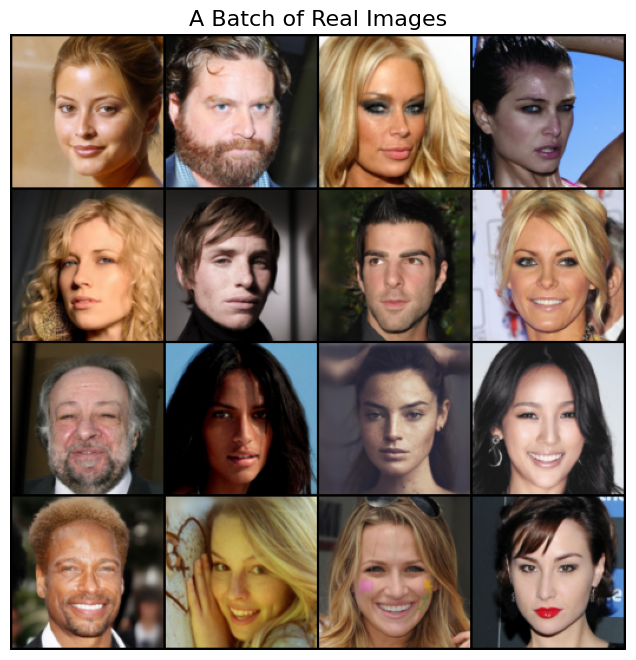

In [4]:
def show_images(images, title="Images", figsize=(8, 8)):
    images = (images.clamp(-1, 1) + 1) / 2 
    grid = make_grid(images, nrow=int(math.sqrt(images.shape[0])))
    
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.show()

real_batch, _ = next(iter(dataloader))
show_images(real_batch[:16], title="A Batch of Real Images")


In [5]:
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(TIMESTEPS)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)
    
    sqrt_alphas_cumprod_t = sqrt_alphas_cumprod.to(x_start.device)[t][:, None, None, None]
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod.to(x_start.device)[t][:, None, None, None]
    
    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


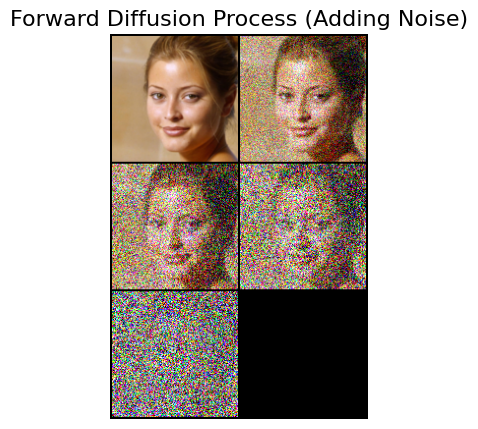

In [6]:
sample_image = real_batch[0:1]
timesteps_to_show = [0, 50, 100, 150, 299]
noisy_stages = []

for t in timesteps_to_show:
    if t == 0:
        noisy_stages.append(sample_image)
    else:
        t_tensor = torch.tensor([t])
        noisy_stages.append(q_sample(sample_image, t_tensor))

show_images(torch.cat(noisy_stages, dim=0), title="Forward Diffusion Process (Adding Noise)", figsize=(15, 5))


In [7]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()
        
    def forward(self, x, t):
        h = self.relu(self.bn1(self.conv1(x)))
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        h = self.relu(self.bn2(self.conv2(h)))
        return h

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = CHANNELS
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = CHANNELS 
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], kernel_size=3, padding=1)

        self.downs = nn.ModuleList([
            ConvBlock(down_channels[0], down_channels[0], time_emb_dim),
            ConvBlock(down_channels[0], down_channels[1], time_emb_dim),
            ConvBlock(down_channels[1], down_channels[2], time_emb_dim)
        ])
        self.pool = nn.MaxPool2d(2)

        self.mid = ConvBlock(down_channels[2], down_channels[2], time_emb_dim)

        self.ups = nn.ModuleList([
            ConvBlock(down_channels[2] + down_channels[2], up_channels[0], time_emb_dim),
            ConvBlock(up_channels[0] + down_channels[1], up_channels[1], time_emb_dim),
            ConvBlock(up_channels[1] + down_channels[0], up_channels[2], time_emb_dim)
        ])
        self.up_sample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.output = nn.Conv2d(up_channels[-1], out_dim, kernel_size=1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        
        x0 = self.conv0(x)
        
        d1 = self.downs[0](x0, t)
        p1 = self.pool(d1)
        
        d2 = self.downs[1](p1, t)
        p2 = self.pool(d2)
        
        d3 = self.downs[2](p2, t)
        p3 = self.pool(d3)
        
        m = self.mid(p3, t)
        
        u1 = self.up_sample(m)
        u1 = torch.cat([u1, d3], dim=1)
        u1 = self.ups[0](u1, t)
        
        u2 = self.up_sample(u1)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.ups[1](u2, t)
        
        u3 = self.up_sample(u2)
        u3 = torch.cat([u3, d1], dim=1)
        u3 = self.ups[2](u3, t)
        
        return self.output(u3)

unet = SimpleUNet().to(device)
param_count = sum(p.numel() for p in unet.parameters())
print(f"Model successfully initialized with {param_count:,} parameters.")


Model successfully initialized with 4,914,019 parameters.


In [8]:
optimizer = optim.AdamW(unet.parameters(), lr=LR)

device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = torch.amp.GradScaler(device_type, enabled=(device_type == 'cuda'))

loss_history = []

print("Starting training...")
for epoch in range(EPOCHS):
    unet.train()
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_images, _ in pbar:
        optimizer.zero_grad()
        batch_images = batch_images.to(device)
        batch_size_current = batch_images.shape[0]
        
        t = torch.randint(0, TIMESTEPS, (batch_size_current,), device=device).long()
        true_noise = torch.randn_like(batch_images)
        x_noisy = q_sample(batch_images, t, noise=true_noise)
        
        with torch.amp.autocast(device_type): 
            predicted_noise = unet(x_noisy, t)
            loss = F.mse_loss(predicted_noise, true_noise)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_epoch_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_epoch_loss)
    print(f"Epoch {epoch+1} Completed | Average Loss: {avg_epoch_loss:.4f}")


Starting training...


Epoch 1/30:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 1 Completed | Average Loss: 0.1093


Epoch 2/30:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 2 Completed | Average Loss: 0.0508


...

Epoch 28 Completed | Average Loss: 0.0261


Epoch 29/30:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 29 Completed | Average Loss: 0.0255


Epoch 30/30:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 30 Completed | Average Loss: 0.0252


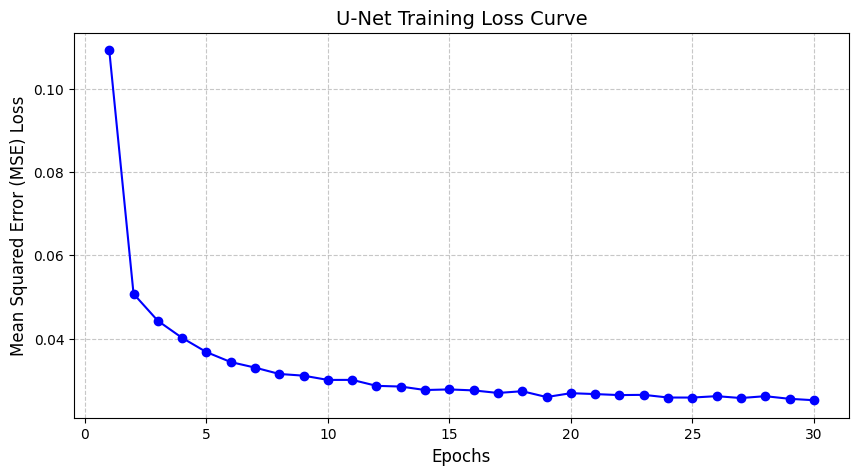

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title("U-Net Training Loss Curve", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (MSE) Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Denoising Generation:   0%|          | 0/300 [00:00<?, ?it/s]

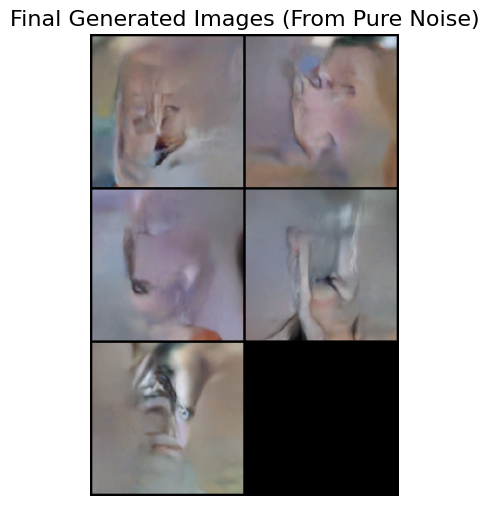

In [10]:
@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = betas.to(device)[t]
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod.to(device)[t]
    sqrt_recip_alphas_t = torch.sqrt(1.0 / alphas.to(device)[t])
    
    pred_noise = model(x, t)
    
    model_mean = sqrt_recip_alphas_t[:, None, None, None] * ( 
        x - betas_t[:, None, None, None] * pred_noise / sqrt_one_minus_alphas_cumprod_t[:, None, None, None]
    )
    
    if t_index == 0:
        return model_mean
    else:
        noise = torch.randn_like(x)
        posterior_variance_t = betas_t
        return model_mean + torch.sqrt(posterior_variance_t)[:, None, None, None] * noise

@torch.no_grad()
def generate_images(model, n_samples=5, track_steps=False):
    model.eval()
    
    x = torch.randn((n_samples, CHANNELS, IMG_SIZE, IMG_SIZE)).to(device)
    steps_history = [x.clone().cpu()]
    
    for i in tqdm(reversed(range(0, TIMESTEPS)), desc='Denoising Generation', total=TIMESTEPS):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, i)
        
        if track_steps and i % (TIMESTEPS // 4) == 0:
            steps_history.append(x.clone().cpu())
            
    if track_steps:
        return x, steps_history
    return x

generated_images, denoising_stages = generate_images(unet, n_samples=5, track_steps=True)
show_images(generated_images.cpu(), title="Final Generated Images (From Pure Noise)", figsize=(12, 6))


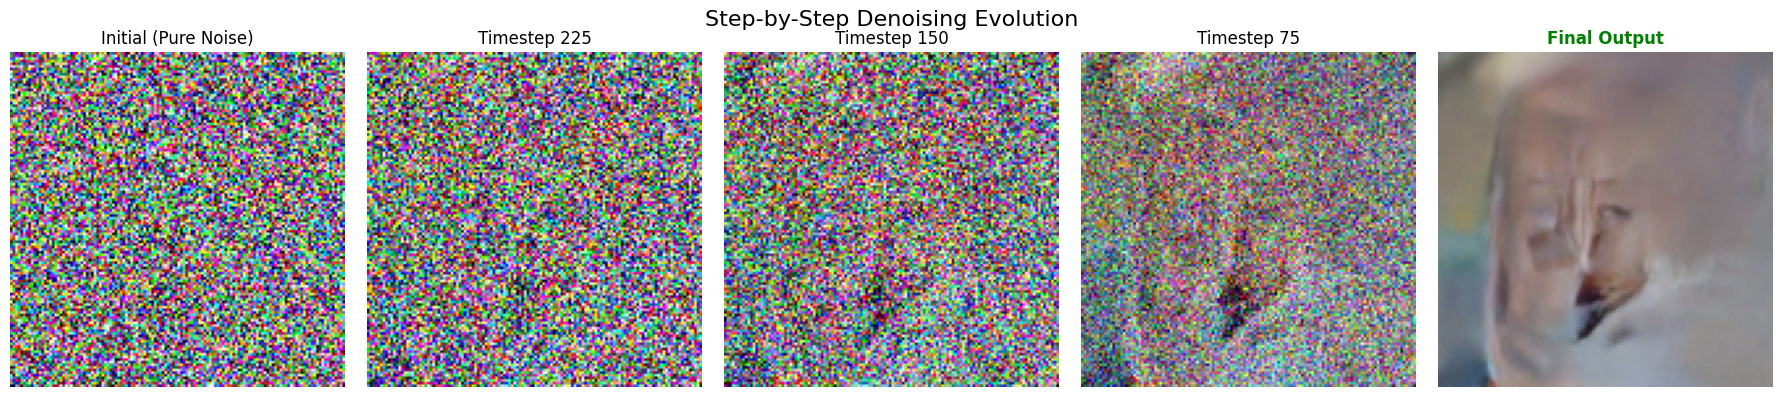

In [11]:
fig, axes = plt.subplots(1, len(denoising_stages), figsize=(18, 4))

for idx, step_batch in enumerate(denoising_stages):
    img = step_batch[0] 
    img = (img.clamp(-1, 1) + 1) / 2
    
    axes[idx].imshow(img.permute(1, 2, 0).numpy())
    axes[idx].axis("off")
    
    if idx == 0:
        axes[idx].set_title("Initial (Pure Noise)", fontsize=12)
    elif idx == len(denoising_stages) - 1:
        axes[idx].set_title("Final Output", fontsize=12, fontweight='bold', color='green')
    else:
        current_step = TIMESTEPS - idx * (TIMESTEPS//4)
        axes[idx].set_title(f"Timestep {current_step}", fontsize=12)

plt.suptitle("Step-by-Step Denoising Evolution", fontsize=16)
plt.tight_layout()
plt.show()


Reconstructing Image: 0it [00:00, ?it/s]

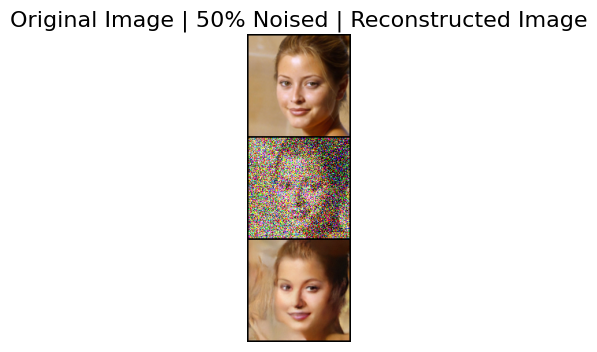

In [12]:
target_image = real_batch[0:1].to(device)
noise_level = TIMESTEPS // 2
t_tensor = torch.tensor([noise_level]).to(device)
noisy_target = q_sample(target_image, t_tensor)

@torch.no_grad()
def reconstruct_image(model, x_noisy, start_t):
    model.eval()
    x = x_noisy.clone()
    
    for i in tqdm(reversed(range(0, start_t)), desc='Reconstructing Image'):
        t = torch.full((1,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, i)
    return x

reconstructed_image = reconstruct_image(unet, noisy_target, noise_level)

comparison = torch.cat([target_image.cpu(), noisy_target.cpu(), reconstructed_image.cpu()])
show_images(comparison, title="Original Image | 50% Noised | Reconstructed Image", figsize=(12, 4))


In [13]:
psnr_metric = PSNR().to(device)
ssim_metric = SSIM().to(device)

t_img_norm = (target_image.clamp(-1, 1) + 1) / 2
r_img_norm = (reconstructed_image.clamp(-1, 1) + 1) / 2

psnr_score = psnr_metric(r_img_norm, t_img_norm)
ssim_score = ssim_metric(r_img_norm, t_img_norm)

print(f"Metrics Evaluation:")
print("-" * 20)
print(f"PSNR Score: {psnr_score.item():.2f} dB")
print(f"SSIM Score: {ssim_score.item():.4f}")


Metrics Evaluation:
--------------------
PSNR Score: 23.96 dB
SSIM Score: 0.6841


In [14]:
@torch.no_grad() 
def generate_with_gradio(seed):
  
    try:
        torch.manual_seed(int(seed.strip()))
    except (ValueError, AttributeError):
        pass 
    
    img = torch.randn((1, CHANNELS, IMG_SIZE, IMG_SIZE)).to(device)
    
    for i in reversed(range(0, TIMESTEPS)):
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = p_sample(unet, img, t, i)
        
    img = (img.clamp(-1, 1) + 1) / 2
    img_np = (img[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    return Image.fromarray(img_np)

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# DDPM Image Synthesizer")
    gr.Markdown("Generate an image from pure noise using our trained Diffusion Model.")
    
    with gr.Row():
        with gr.Column():
            seed_input = gr.Textbox(label="Random Seed (Optional)", placeholder="e.g., 42 for reproducible results")
            gen_btn = gr.Button("Generate Image", variant="primary")
        with gr.Column():
            output_image = gr.Image(label="Generated Output")
    
    gen_btn.click(fn=generate_with_gradio, inputs=seed_input, outputs=output_image)

demo.launch(share=True, inline=True)


/tmp/ipykernel_23/798656098.py:19: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a68d737f118f63975c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
